
%load_ext autoreload
%autoreload 2

# Introduction


Un bateau navigue dans une région soumise à un vent fort et cherche à atteindre une cible en temps minimal en choisissant à chaque instant sa direction de propulsion.

Le domaine dans lequel navigue le bateau est un anneau $\Omega = \{(x,y) \in \mathbb{R}^2 : r^2 < x^2 + y^2 < R^2\}$. Le vent souffle principalement le long de l'axe $x$ avec une intensité variable :

$$
v_c(x,y) = 1 - a\sin\!\left(\pi\frac{x^2+y^2-r^2}{R^2-r^2}\right),
$$

qui est maximale au bord de l'anneau. La dynamique du bateau est gouvernée par l'équation différentielle stochastique contrôlée

$$
\begin{pmatrix}dX_t \\ dY_t\end{pmatrix} = \begin{pmatrix}v_c(X_t,Y_t) + v_s\cos\alpha_t \\ v_s\sin\alpha_t\end{pmatrix}dt + \begin{pmatrix}\sigma_x & 0 \\ 0 & \sigma_y\end{pmatrix}dW_t, \qquad (X_0, Y_0) = x \in \Omega,
$$

où $\alpha_t \in [0,2\pi]$ est la direction instantanée choisie par le pilote, $v_s > 0$ la vitesse propre du bateau, et $(W_t)$ un mouvement brownien bidimensionnel modélisant la perturbation aléatoire du vent.

L'objectif est de minimiser le temps de sortie $\tau = \inf\{t \geq 0 : (X_t, Y_t) \notin \Omega\}$, le premier temps de sortie du domaine tumultueux, tout en tenant compte d'une incertitude sur la loi du bruit, modélisée par un ensemble $\mathcal{M}$ de mesures de probabilité équivalentes. Mathématiquement, 
$$
\mathcal{M} = \left\{ Q \ll P \ \middle|\ \frac{dQ}{dP}\bigg|_{\mathcal{F}_t} = \exp\!\left(\int_0^t \beta_s \cdot dW_s - \frac{1}{2}\int_0^t \|\beta_s\|^2\,ds\right),\ \{\beta_t\}_{t\geq 0} \text{ adapté},\ \|\beta_t\|_\infty \leq \kappa\ \forall t \right\}
$$

## Fonction valeur \& equation de HBJI

Le problème stochastique s'écrit ainsi :

$$
\begin{aligned}
u(x) &= \inf_{\alpha_t \in [0, 2\pi]} \sup_{Q \in \mathcal{M}} \mathbb{E}^Q\!\left[\int_0^\tau f(X_t)\,dt + g(X_\tau)\right],\\
g &\equiv 0 \text{ sur }  \partial B_r \\
g &\equiv 1  \text{ sur }  \partial B_R
\end{aligned}
$$

Par le principe de programmation dynamique, la fonction valeur $u$ est l'unique solution de viscosité d'une équation de Hamilton–Jacobi–Bellman–Isaacs (HJBI) :

$$
\begin{aligned}
F(u) &= -\frac{1}{2}\left(\sigma_x^2 u_{xx} + \sigma_y^2 u_{yy}\right) - v_c\, u_x - v_s \inf_{\alpha \in [0, 2\pi]} \left\{ (\cos \alpha, \sin \alpha) \cdot \nabla u \right\} - \sup_{\|\beta\|_\infty \leq \kappa} \left\{ \beta \cdot (\sigma \nabla u) \right\} - f \\
&= -\frac{1}{2}\left(\sigma_x^2 u_{xx} + \sigma_y^2 u_{yy}\right) - v_c\, u_x + v_s\|\nabla u\|_2 - \kappa\|\sigma\nabla u\|_1 - f \\
&= 0 \quad \text{dans } \Omega,
\end{aligned}
$$

avec $u = 0$ sur $\partial B_r$ et $u = 1$ sur $\partial B_R$.
En résolvant manuellement cette equation, on obtient que les paramètres optimaux sont :
$$
\begin{cases}
\alpha^* = \pi + \theta, \quad \text{où } \theta = \operatorname{atan2}(u_y, u_x), \\
\\
\beta^* = \kappa 
\begin{pmatrix}
\operatorname{sgn}(\sigma_x u_x) \\
\operatorname{sgn}(\sigma_y u_y)
\end{pmatrix}
\end{cases}
$$


## Objectif

Dans ce projet, nous nous proposons de résoudre numériquement ce problème avec deux approches, afin de déterminer laquelle est la meilleure.
Il s'agit de :
* une **méthode aux différences finies**, permettant d’obtenir une solution de référence précise en discrétisant directement l’équation HJBI sur une grille adaptée au domaine ;
* une **approche par réseaux de neurones de type Physics-Informed Neural Networks (PINNs)**, qui consiste à approximer la solution en minimisant le résidu de l’équation différentielle à l’aide de techniques d’apprentissage.

L’objectif sera d’analyser et de comparer ces deux méthodes en termes de précision, de coût de calcul et de robustesse face aux non-linéarités induites par le contrôle optimal et l’incertitude sur le bruit. 


### Deux scénarios étudiés

* Scénario 1 : On considère que la solution exacte de l'équation est donnée par :
    $$
    u_{ex} = sin\left(\pi\frac{x^2+y^2-r^2}{R^2-r^2}\right).
    $$

    Cette fonction permet d'extraire le coût de temps $f$ en injectant $u_{ex}$ dans l'équation de HJBI. En effet, on trouve que $f$ est donné par :
    $$
    f(x,y) = -\frac{1}{2}(\sigma_x^2 u_{ex,xx} + \sigma_y^2 u_{ex,yy}) - v_c u_{ex,x} + v_s\|\nabla u_{ex}\|_{\ell^2} - \kappa\|\sigma\nabla u_{ex}\|_{\ell^1}.
    $$

    Cela permet d'avoir une solution exacte pour tester les méthodes numériques.

* Scénario 2 : Dans ce scénario, on considère que le coût de temps est constant, i.e. $f=1$.



In [40]:
# Packages

import numpy as np
import torch
import torch.nn as nn
import time
from scipy.stats import qmc
import matplotlib.pyplot as plt
import pandas as pd
import importlib

import fonctions_NN as fnn
np.random.seed(1234)
torch.manual_seed(1234)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Approche par réseaux de neurones

## Méthode PINNs/DGM


L’idée centrale de la méthode des PINNs, proposée par Raissi, est d’approximer la solution inconnue $u(x)$ par une fonction paramétrée $u_\theta(x)$, représentée par un réseau de neurones profond. Cette approximation est dite globale, au sens où le réseau est entraîné pour représenter la solution sur l’ensemble du domaine.

La spécificité de l’approche PINNs réside dans la manière dont l’équation est prise en compte. À partir du réseau $u_\theta$, on construit plusieurs résidus :

* le résidu de l’équation, noté $F_\theta(u)$, dans lequel les dérivées sont calculées à l’aide de l’**automatic differentiation**, c’est-à-dire en dérivant directement le réseau par rapport à ses entrées. Cela permet d’obtenir des dérivées exactes au sens numérique, sans introduire d’erreur de discrétisation. Ce résidu mesure à quel point la fonction approchée $u_\theta$ viole l’équation HJBI ;

* le résidu sur le bord intérieur, correspondant à la condition de Dirichlet sur $\partial B_r$, de la forme $u_\theta(x) - 0,$ qui mesure l’écart à la condition $u = 0$ sur $\partial B_r$ ;

* le résidu sur le bord extérieur, correspondant à la condition sur $\partial B_R$, de la forme $u_\theta(x) - 1,$ qui mesure l’écart à la condition $u = 1$ sur $\partial B_R$.

L'idée étant de déterminer le paramètre qui minimise ces résidus.


## Méthode policy iteration

Contrairement aux approches classiques de type PINNs “directes”, qui consistent à minimiser le résidu de l’équation non linéaire, la méthode proposée repose sur une idée clé : *transformer le problème non linéaire en une suite de problèmes linéaires*, plus simples à résoudre.

Cette stratégie repose sur une *policy iteration*, analogue à une méthode de Newton semi-smooth pour les équations HJBI.
Étant donné que l’équation HJBI est non linéaire, et en général ni convexe ni concave en $\nabla u$, sa résolution directe constitue un problème délicat, tant du point de vue analytique que numérique. L’idée de la méthode est donc de figer les contrôles $(\alpha, \beta)$ à chaque itération, afin de linéariser l’équation.

Plus précisément, à partir d’une approximation $u^k$ de la solution, on détermine les contrôles optimaux associés en utilisant les expressions explicites obtenues précédemment. Ces contrôles dépendent du gradient de $u^k$ et sont donc calculés point par point dans le domaine. Une fois ces contrôles fixés, l’équation HJBI se réduit à une équation elliptique linéaire en $u^{k+1}$, dont les coefficients dépendent des contrôles gelés.

On obtient ainsi une équation de la forme
$$
F(u^{k+1}) = -\frac{1}{2}\left(\sigma_x^2 u_{xx}^{k+1} + \sigma_y^2 u_{yy}^{k+1} \right) - v_c\, u_x^{k+1} - v_s\left\{ (\cos \alpha^*, \sin \alpha^*) \cdot \nabla u^{k+1} \right\} - \left\{ \beta^* \cdot (\sigma \nabla u^{k+1}) \right\} - f.
$$

Cette équation linéaire peut alors être résolue à l’aide d’une méthode numérique adaptée. Dans notre cadre, nous choisissons de l’approximer à l’aide d’un réseau de neurones, en minimisant le résidu de cette équation linéaire, ce qui simplifie considérablement le problème d’optimisation par rapport à l’approche PINNs directe.
Le procédé est ensuite itéré : la solution $u^{k+1}$ ainsi obtenue permet de recalculer de nouveaux contrôles $(\alpha^{k+1}, \beta^{k+1})$, et ainsi de suite jusqu’à convergence. Cette approche s’apparente à une méthode de Newton semi-smooth, et bénéficie en pratique de propriétés de convergence rapides, tout en évitant les difficultés liées à la non-linéarité initiale de l’équation HJBI.


## Schéma de résolution

Pour pouvoir résoudre le problème de Zermelo, nous avons fait le choix de simuler le domaine par quasi-Monte Carlo.

On considère des réseaux de neurones fully-connected à 4 couches, avec activation $\tanh$, dont la profondeur et la largeur sont égaux à $H=100$.
Le choix des points de collocation est crucial : une grille régulière devient rapidement inapplicable en grande dimension, et les points pseudo-aléatoires classiques présentent une mauvaise répartition.

Pour générer $N=10000$ points de collocation, nous allons utiliser une méthode quasi-Monte Carlo (QMC) basée sur des séquences à faible discrépance. En particulier, nous allons d'abord définir des points dans $[0,2]^2$ à partir de la séquence de Halton généralisée, puis mapper ces points dans l'anneau via la transformation polaire $(x,y) \mapsto (l cos(\phi),l sin(\phi))$, où $l= (R^2 - r^2)x + r^2$ et $\phi = 2\pi y$ pour tous les points $(x,y) \in [0,1]^2$.
Les points du bords seront également générés par quasi-Monte Carlo avec $N_b = N = 10000$.

L’entraînement du réseau est réalisé par descente de gradient stochastique avec l’algorithme Adam, en utilisant des mini-batchs $B=100$ de points de collocation et un taux d’apprentissage $lr=1e-3$.
Pour chaque méthode, nous avons utilisé des mini-batchs de taille 100 et effectué 200 itérations/epochs.
Par ailleurs, pour évaluer la pertinence globale des méthodes, nous avons utilisé un échantillon de validation simulé avec un maillage cartésien similaire à celui utilisé pour les différences finies.


In [41]:
importlib.reload(fnn)

# Paramètres
params = {
    'r': 0.5,           # rayon intérieur
    'R': np.sqrt(2),    # rayon extérieur
    'sigma_x': 0.5,     # diffusion selon x
    'sigma_y': 0.2,     # diffusion selon y
    'a': 0.2,          # variation spatiale du v_c (cas analytique)
    'v_s': 0.5,         # vitesse du bateau
    'kappa': 0.1,        # intensité adversaire
    'f' : None           # terme source (None pour cas analytique)
}

## Résultats 

### PINNs Direct Method

#### Cas analytique

On considère le cas où on a l'expression analytique de la solution, donnée par :
$$u(x,y) = \frac{1}{2} sin( \frac{\pi}{2} \frac{x^2 + y^2 - r^2}{R^2 - r^2})$$

On peut alors calculer le terme source $f$ à partir de l'équation de Zermelo :
$$f(x,y) = -\frac{1}{2}(\sigma_x^2 u_{xx} + \sigma_y^2 u_{yy}) - v_c u_x + v_s\|\nabla u\|_{\ell^2} - \kappa\|\sigma\nabla u\|_{\ell^1}$$

In [42]:
# Paramètres du PINN
H = 100 
N_F   = 10000 # points intérieurs
N_b  = 1000 # points sur chaque bord
N_val = 200 # points pour validation
epochs = 200
batch_size = 100


# Parameters
from pprint import pprint

print("Paramètres : \n")
pprint(params)
print(f'Nombres de neurones par couches : {H}')
print(f'Nombre de points au bord : {N_b}')
print(f'Nombre de points intérieurs : {N_F}')
print(f'Nombre de points de validation : {N_val}')
# Total de batch
print(f"Nombre de batchs: {(N_F + batch_size - 1) // batch_size}")


Paramètres : 

{'R': np.float64(1.4142135623730951),
 'a': 0.2,
 'f': None,
 'kappa': 0.1,
 'r': 0.5,
 'sigma_x': 0.5,
 'sigma_y': 0.2,
 'v_s': 0.5}
Nombres de neurones par couches : 100
Nombre de points au bord : 1000
Nombre de points intérieurs : 10000
Nombre de points de validation : 200
Nombre de batchs: 100


In [43]:
# Simulation des points de données
# Echantillons pour l'entraînement
# Parameters

tmp_pts = fnn.simuler_pts_interieur(N = N_F, r = params['r'], R = params['R'])
X_F = torch.tensor(tmp_pts, dtype=torch.float32, device=device)

#Bords
tmp_pts = fnn.simuler_pts_theta(N=N_b)
theta1 = torch.tensor(tmp_pts, dtype=torch.float32, device=device)

tmp_pts = fnn.simuler_pts_theta(N=N_b)
theta2 = torch.tensor(tmp_pts, dtype=torch.float32, device=device)

X_b_r = torch.stack([params['r'] * torch.cos(theta1), params['r'] * torch.sin(theta1)], dim=1)
X_b_R = torch.stack([params['R'] * torch.cos(theta1), params['R'] * torch.sin(theta1)], dim=1)

g_bord_r = torch.zeros(N_b, 1, device=device)
g_bord_R = torch.ones(N_b, 1, device=device)


# # Echantillons pour la validation (pour points de collocation)
# x = np.linspace(-params['R'], params['R'], N_val)
# y = np.linspace(-params['R'], params['R'], N_val)
# X, Y = np.meshgrid(x, y)
# rho = np.sqrt(X**2 + Y**2)
# mask = (rho >= params['r']) & (rho <= params['R'])
# X_flat = X[mask]
# Y_flat = Y[mask]
# X_val = torch.tensor(np.stack([X_flat, Y_flat], axis=1),dtype=torch.float32,device=device)

Xmin, Xmax = -2,2
Ymin, Ymax = -2,2
hx = (Xmax - Xmin) / (N_val + 1)
hy = (Ymax - Ymin) / (N_val + 1)
x = Xmin + hx * np.arange(1, N_val + 1)
y = Ymin + hy * np.arange(1, N_val + 1)

X, Y = np.meshgrid(x, y)
rho = np.sqrt(X**2 + Y**2)
mask = (rho >= params['r']) & (rho <= params['R'])
X_flat = X[mask]
Y_flat = Y[mask]
X_val = torch.tensor(np.stack([X_flat, Y_flat], axis=1),dtype=torch.float32,device=device)



In [44]:
# Initialisation du modèle
importlib.reload(fnn)

tol = 1e-2
model = fnn.NeuralNetwork_DGM(X_F,X_b_r, X_b_R, g_bord_r, g_bord_R, X_val, params, H=H, device=device).to(device)

df = []

with torch.no_grad():
    u_old = torch.zeros(len(X_val), 1, device=device)

u_real = fnn.u_etoile(X_val,params["r"],params["R"])

start = time.time()
for t in range(epochs):
    print(f"Epoch {t + 1}\n=================================")
    loss,loss_pde,loss_bc = model.train_1epoch(batch_size=batch_size)
    val_loss,val_loss_pde,val_loss_bc = model.validation_loss()
    u_k = model(X_val)
    err_ex = model.evaluate()

    elapsed = time.time() - start
    print(f"\n-----------------------------------\nTemps écoulé : {elapsed:.2f} s")
    err = torch.norm(u_k-u_old)/torch.norm(u_old)
    u_old = u_k.detach().clone()
    q_k = torch.norm(u_k-u_real)/torch.norm(u_old - u_real)

    df.append({
        "Loss Total": loss.item(),
        "Loss HJBI": loss_pde.item(),
        "Loss Bords": loss_bc.item(),
        "Validation Loss Total": val_loss.item(),
        "Validation Loss HJBI": val_loss_pde.item(),
        "Validation Loss Bords": val_loss_bc.item(),
        "Erreur": err.item(),
        "Erreur exacte": err_ex.item(),
        "Order":q_k.item(),
        "Temps": elapsed
    })

    print(  f"\nValidation loss | Total : {val_loss:.3e} | HBJI : {val_loss_pde:.3e} | Bords : {val_loss_bc:.3e}\n"
            f"Erreur exacte : {err_ex:.3e}, Erreur : {err:.3e} \n"
        )
    
    # STOP GLOBAL
    # if err <= tol:
    #     print("Convergence atteinte.")
    #     break
df_pinns_1 = pd.DataFrame(df)

Epoch 1
Loss - Total: 1.340e+00 | HJBI: 6.754e-01 | Bords: 6.646e-01
Loss - Total: 1.205e+00 | HJBI: 5.729e-01 | Bords: 6.324e-01
Loss - Total: 1.040e+00 | HJBI: 4.307e-01 | Bords: 6.095e-01
Loss - Total: 9.752e-01 | HJBI: 4.425e-01 | Bords: 5.326e-01
Loss - Total: 8.176e-01 | HJBI: 3.089e-01 | Bords: 5.087e-01
Loss - Total: 6.377e-01 | HJBI: 2.274e-01 | Bords: 4.103e-01
Loss - Total: 4.441e-01 | HJBI: 1.245e-01 | Bords: 3.195e-01
Loss - Total: 2.958e-01 | HJBI: 9.457e-02 | Bords: 2.013e-01
Loss - Total: 1.746e-01 | HJBI: 6.030e-02 | Bords: 1.143e-01
Loss - Total: 2.183e-01 | HJBI: 1.553e-01 | Bords: 6.300e-02
Loss - Total: 1.717e-01 | HJBI: 1.418e-01 | Bords: 2.989e-02
Loss - Total: 8.033e-02 | HJBI: 6.950e-02 | Bords: 1.083e-02
Loss - Total: 1.012e-01 | HJBI: 8.835e-02 | Bords: 1.290e-02
Loss - Total: 9.047e-02 | HJBI: 8.318e-02 | Bords: 7.294e-03
Loss - Total: 8.690e-02 | HJBI: 8.013e-02 | Bords: 6.772e-03
Loss - Total: 4.185e-02 | HJBI: 3.561e-02 | Bords: 6.243e-03
Loss - Total: 7.

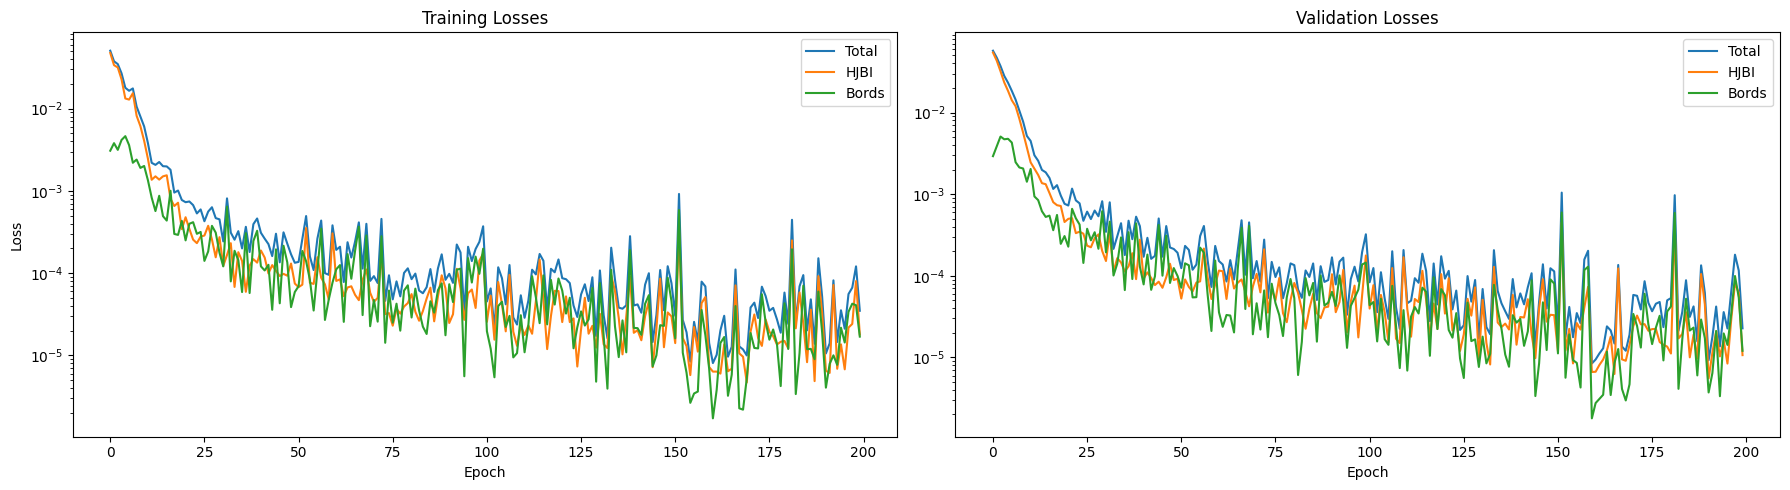

In [45]:
fig, ax = plt.subplots(1,2, figsize=(18,5))

# Training
ax[0].plot(df_pinns_1["Loss Total"], label="Total")
ax[0].plot(df_pinns_1["Loss HJBI"], label="HJBI")
ax[0].plot(df_pinns_1["Loss Bords"], label="Bords")
ax[0].set_title("Training Losses")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_yscale("log")
ax[0].legend()

# Validation
ax[1].plot(df_pinns_1["Validation Loss Total"], label="Total")
ax[1].plot(df_pinns_1["Validation Loss HJBI"], label="HJBI")
ax[1].plot(df_pinns_1["Validation Loss Bords"], label="Bords")
ax[1].set_title("Validation Losses")
ax[1].set_xlabel("Epoch")
ax[1].set_yscale("log")
ax[1].legend()

plt.tight_layout()
plt.show()

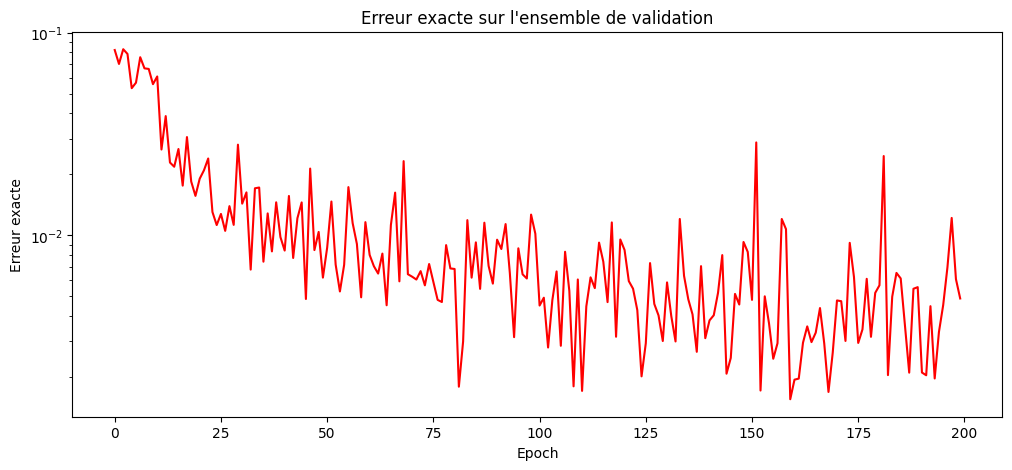

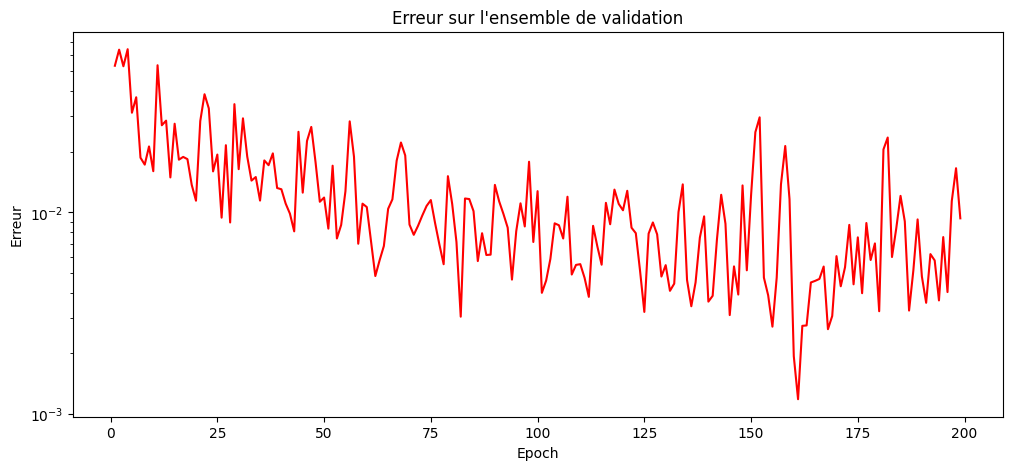

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(df_pinns_1["Erreur exacte"], color='red')
plt.title("Erreur exacte sur l'ensemble de validation")
plt.xlabel("Epoch")
plt.ylabel("Erreur exacte")
plt.yscale("log")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_pinns_1["Erreur"], color='red')
plt.title("Erreur sur l'ensemble de validation")
plt.xlabel("Epoch")
plt.ylabel("Erreur")
plt.yscale("log")
plt.show()

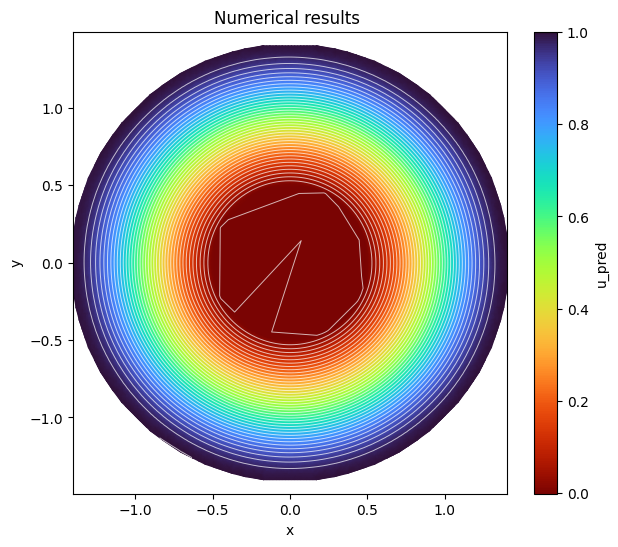

In [47]:
X_val = model.X_val

model.eval()
with torch.no_grad():
    u_pred = model(X_val).cpu().numpy()

x = X_val[:,0].cpu().numpy()
y = X_val[:,1].cpu().numpy()
u = u_pred.flatten()

plt.figure(figsize=(7,6))

# heatmap
heat = plt.tripcolor(x, y, u, shading="gouraud", cmap="turbo_r")

# lignes de niveau
plt.tricontour(x, y, u,levels=40,colors="white",linewidths=0.7,alpha=0.7)

# jauge de couleur associée à la heatmap
plt.colorbar(heat, label="u_pred")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerical results ")

plt.axis("equal")

plt.show()

#### Cas avec f=1

In [48]:
params['f']=1

# Initialisation du modèle
tol = 1e-2
model = fnn.NeuralNetwork_DGM(X_F,X_b_r, X_b_R, g_bord_r, g_bord_R, X_val, params, H=H, device=device).to(device)

df = []

with torch.no_grad():
    u_old = torch.zeros(len(X_val), 1, device=device)
    
start = time.time()
for t in range(epochs):
    print(f"Epoch {t + 1}\n=================================")
    loss,loss_pde,loss_bc = model.train_1epoch(batch_size=batch_size)
    val_loss,val_loss_pde,val_loss_bc = model.validation_loss()
    u_k = model(X_val)
    err_ex = model.evaluate()

    elapsed = time.time() - start
    print(f"\n-----------------------------------\nTemps écoulé : {elapsed:.2f} s")
    err = torch.norm(u_k-u_old)/torch.norm(u_old)
    u_old = u_k.detach().clone()

    df.append({
        "Loss Total": loss.item(),
        "Loss HJBI": loss_pde.item(),
        "Loss Bords": loss_bc.item(),
        "Validation Loss Total": val_loss.item(),
        "Validation Loss HJBI": val_loss_pde.item(),
        "Validation Loss Bords": val_loss_bc.item(),
        "Erreur": err.item(),
        "Temps": elapsed
    })

    print(  f"\nValidation loss | Total : {val_loss:.3e} | HBJI : {val_loss_pde:.3e} | Bords : {val_loss_bc:.3e}\n"
            f"Erreur : {err:.3e} \n"
        )
    
    # STOP GLOBAL
    # if err <= tol:
    #     print("Convergence atteinte.")
    #     break
df_pinns_2 = pd.DataFrame(df)

Epoch 1
Loss - Total: 1.030e+00 | HJBI: 2.445e-01 | Bords: 7.857e-01
Loss - Total: 1.102e+00 | HJBI: 8.156e-02 | Bords: 1.020e+00
Loss - Total: 1.007e+00 | HJBI: 2.898e-01 | Bords: 7.168e-01
Loss - Total: 9.482e-01 | HJBI: 2.386e-01 | Bords: 7.096e-01
Loss - Total: 9.206e-01 | HJBI: 1.223e-01 | Bords: 7.983e-01
Loss - Total: 8.503e-01 | HJBI: 1.449e-01 | Bords: 7.054e-01
Loss - Total: 8.226e-01 | HJBI: 2.214e-01 | Bords: 6.013e-01
Loss - Total: 7.903e-01 | HJBI: 1.812e-01 | Bords: 6.091e-01
Loss - Total: 6.993e-01 | HJBI: 1.653e-01 | Bords: 5.340e-01
Loss - Total: 6.355e-01 | HJBI: 2.160e-01 | Bords: 4.195e-01
Loss - Total: 5.490e-01 | HJBI: 1.769e-01 | Bords: 3.721e-01
Loss - Total: 4.558e-01 | HJBI: 2.026e-01 | Bords: 2.533e-01
Loss - Total: 4.251e-01 | HJBI: 1.746e-01 | Bords: 2.505e-01
Loss - Total: 3.879e-01 | HJBI: 1.597e-01 | Bords: 2.282e-01
Loss - Total: 4.534e-01 | HJBI: 2.224e-01 | Bords: 2.311e-01
Loss - Total: 4.352e-01 | HJBI: 2.497e-01 | Bords: 1.855e-01
Loss - Total: 4.

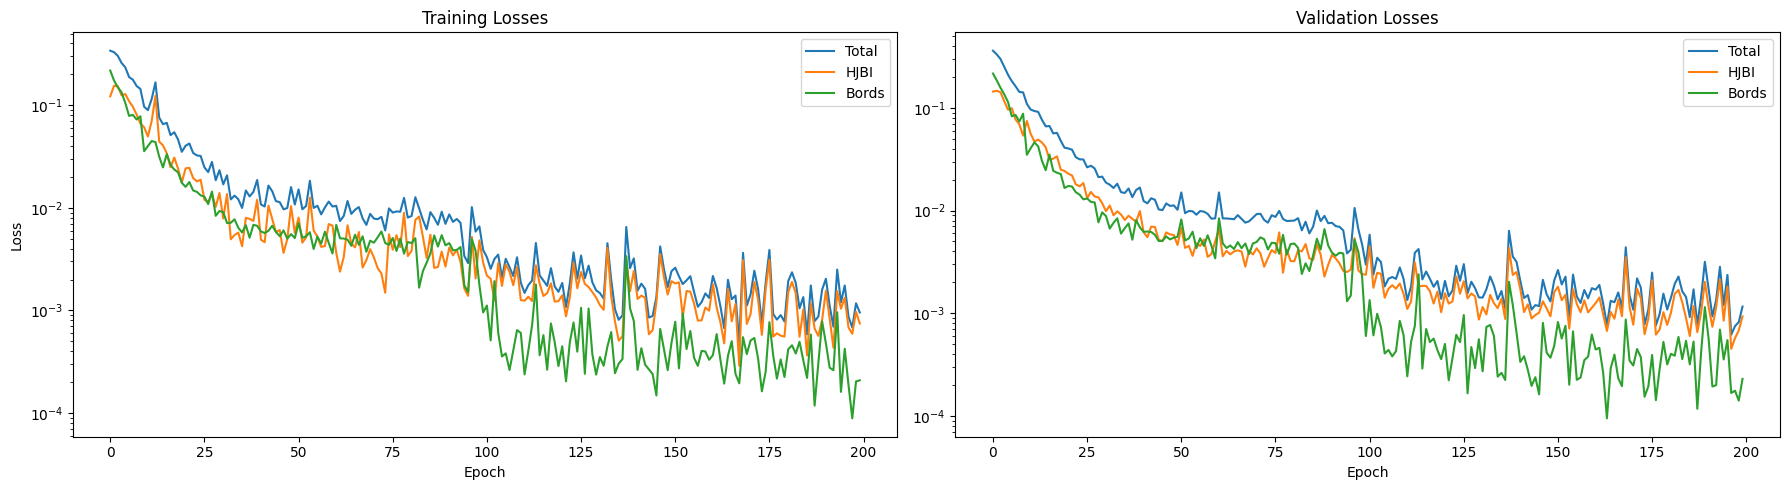

In [49]:
fig, ax = plt.subplots(1,2, figsize=(18,5))

# Training
ax[0].plot(df_pinns_2["Loss Total"], label="Total")
ax[0].plot(df_pinns_2["Loss HJBI"], label="HJBI")
ax[0].plot(df_pinns_2["Loss Bords"], label="Bords")
ax[0].set_title("Training Losses")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_yscale("log")
ax[0].legend()

# Validation
ax[1].plot(df_pinns_2["Validation Loss Total"], label="Total")
ax[1].plot(df_pinns_2["Validation Loss HJBI"], label="HJBI")
ax[1].plot(df_pinns_2["Validation Loss Bords"], label="Bords")
ax[1].set_title("Validation Losses")
ax[1].set_xlabel("Epoch")
ax[1].set_yscale("log")
ax[1].legend()

plt.tight_layout()
plt.show()

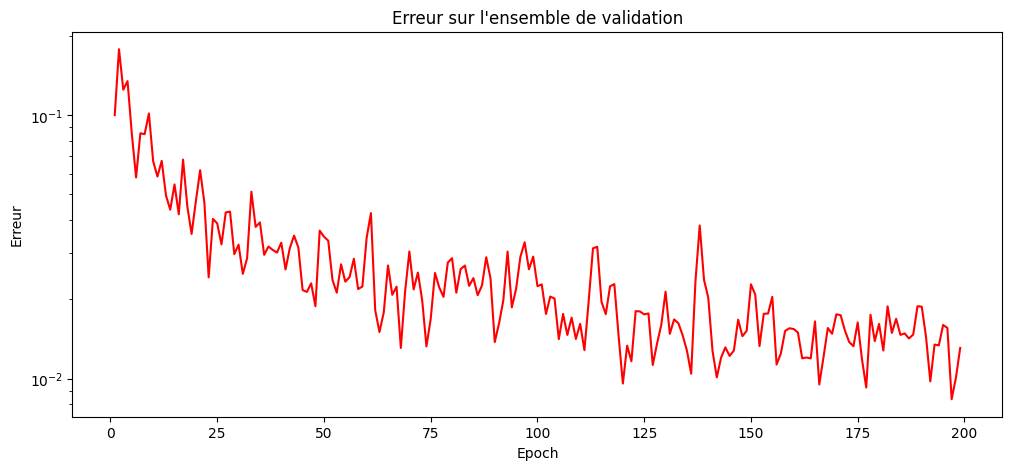

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(df_pinns_2["Erreur"], color='red')
plt.title("Erreur sur l'ensemble de validation")
plt.xlabel("Epoch")
plt.ylabel("Erreur")
plt.yscale("log")
plt.show()

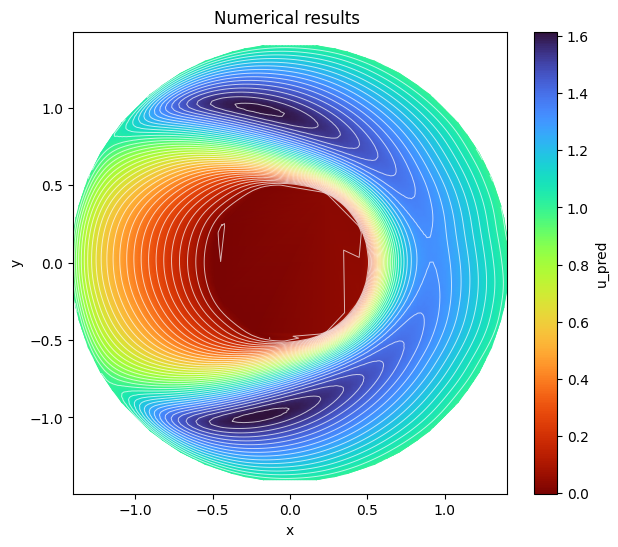

In [51]:
X_val = model.X_val

model.eval()
with torch.no_grad():
    u_pred = model(X_val).cpu().numpy()

x = X_val[:,0].cpu().numpy()
y = X_val[:,1].cpu().numpy()
u = u_pred.flatten()

plt.figure(figsize=(7,6))

# heatmap
heat = plt.tripcolor(x, y, u, shading="gouraud", cmap="turbo_r")

# lignes de niveau
plt.tricontour(x, y, u,levels=40,colors="white",linewidths=0.7,alpha=0.7)

# jauge de couleur associée à la heatmap
plt.colorbar(heat, label="u_pred")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerical results ")

plt.axis("equal")

plt.show()

### Inexact policy iteration

In [52]:
importlib.reload(fnn)
# Params policy
kmax = 200
tol = 1e-2
eta_0 = 40.0
max_iter_ = 200

#### Cas analytique

In [53]:
# Parameters
from pprint import pprint

params['f']=None

print("Paramètres : \n")
pprint(params)
print(f'Nombre de points au bord : {N_b}')
print(f'Nombre de points intérieurs : {N_F}')
print(f'Nombre de points de validation : {N_val}')

Paramètres : 

{'R': np.float64(1.4142135623730951),
 'a': 0.2,
 'f': None,
 'kappa': 0.1,
 'r': 0.5,
 'sigma_x': 0.5,
 'sigma_y': 0.2,
 'v_s': 0.5}
Nombre de points au bord : 1000
Nombre de points intérieurs : 10000
Nombre de points de validation : 200


In [54]:
# INIT
net = fnn.NeuralNet().to(device)


# INITIALISATION
with torch.no_grad():
    u_k = net(X_val).detach().clone()
u_old = torch.zeros_like(u_k)
u_real = fnn.u_etoile(X_val,params["r"],params["R"])


start = time.time()

# BOUCLE PRINCIPALE 
df = []
for k in range(1, kmax + 1):
    print(f"Iteration {k}\n=================================")

    # Reset optimizer à chaque itération k (important)
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    eta_k = 2 ** (-k)

    # norme précédente
    diff_prev = torch.norm(u_k - u_old).item()
    threshold = eta_k * min(diff_prev, eta_0)

    Jk = float("inf")
    # BOUCLE SGD
    it = 0
    while True:

        perm = torch.randperm(N_F, device=device)

        for i in range(0, N_F, batch_size):
            idx = perm[i:i+batch_size]
            X_batch = X_F[idx].clone().detach().requires_grad_(True)

            hjbi_loss = fnn.pde_residual_loss(net, X_batch, params)
            bord_loss_r = fnn.boundary_l2_loss(net, X_b_r, g_bord_r, params['r'])
            bord_loss_R = fnn.boundary_l2_loss(net, X_b_R, g_bord_R, params['R'])
            h32_r = fnn.boundary_h32(net, theta1, theta2, params['r'])
            h32_R = fnn.boundary_h32(net, theta1, theta2, params['R'])

            loss = hjbi_loss + \
                   (bord_loss_r + 0.1 * h32_r) + \
                   (bord_loss_R + 0.1 * h32_R)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()

        # EVALUATION GLOBALE
        Jk_full, hjbi_full, loss_br, loss_bR = fnn.full_loss(net, X_val, params,X_b_r,X_b_R,g_bord_r,g_bord_R,theta1,theta2)
        Jk = Jk_full.item()

        # condition d'arrêt interne
        it += 1
        if (Jk < threshold) or (it < max_iter_):
            break

    # UPDATE u_k
    u_old = u_k.clone()
    with torch.no_grad():
        u_k = net(X_val).detach().clone()

    # ERREURS
    err = torch.norm(u_k - u_old) / (torch.norm(u_old) + 1e-12)
    u_real = fnn.u_etoile(X_val, params["r"], params["R"])
    
    err_ex = torch.norm(u_k - u_real) / torch.norm(u_real)
    q_k = torch.norm(u_k-u_real)/torch.norm(u_old - u_real)

    elapsed = time.time() - start
    print(f"Temps écoulé : {elapsed:.2f} s\n-----------------------------------")
    df.append({
    "Loss Total": Jk,
    "Loss HJBI": hjbi_full.item(),
    "Loss Bords": (loss_br.item() + loss_bR.item()),
    "Erreur": err.item(),
    "Erreur exacte": err_ex.item(),
    "Temps": elapsed,
    "Order":q_k.item(),
    })

    print(f"Loss Total : {Jk:.3e} | HBJI : {hjbi_full:.3e} | Loss bords : {loss_br + loss_bR:.3e} \n"
          f"Erreur exacte : {err_ex:.3e} | Erreur :{err:.3e}\n")


    # STOP GLOBAL
    # if err <= tol:
    #     print("Convergence atteinte.")
    #     break

df_PI1 = pd.DataFrame(df)

Iteration 1
Temps écoulé : 1.70 s
-----------------------------------
Loss Total : 5.722e-01 | HBJI : 3.021e-01 | Loss bords : 2.569e-02 
Erreur exacte : 8.885e-02 | Erreur :1.595e+01

Iteration 2
Temps écoulé : 3.40 s
-----------------------------------
Loss Total : 4.365e-01 | HBJI : 2.314e-01 | Loss bords : 1.621e-02 
Erreur exacte : 7.278e-02 | Erreur :7.627e-02

Iteration 3
Temps écoulé : 5.09 s
-----------------------------------
Loss Total : 3.342e-01 | HBJI : 1.631e-01 | Loss bords : 1.411e-02 
Erreur exacte : 7.038e-02 | Erreur :1.895e-02

Iteration 4
Temps écoulé : 6.74 s
-----------------------------------
Loss Total : 2.421e-01 | HBJI : 1.028e-01 | Loss bords : 1.435e-02 
Erreur exacte : 5.902e-02 | Erreur :3.065e-02

Iteration 5
Temps écoulé : 8.42 s
-----------------------------------
Loss Total : 1.814e-01 | HBJI : 7.006e-02 | Loss bords : 7.741e-03 
Erreur exacte : 4.755e-02 | Erreur :2.320e-02

Iteration 6
Temps écoulé : 10.12 s
-----------------------------------
Loss

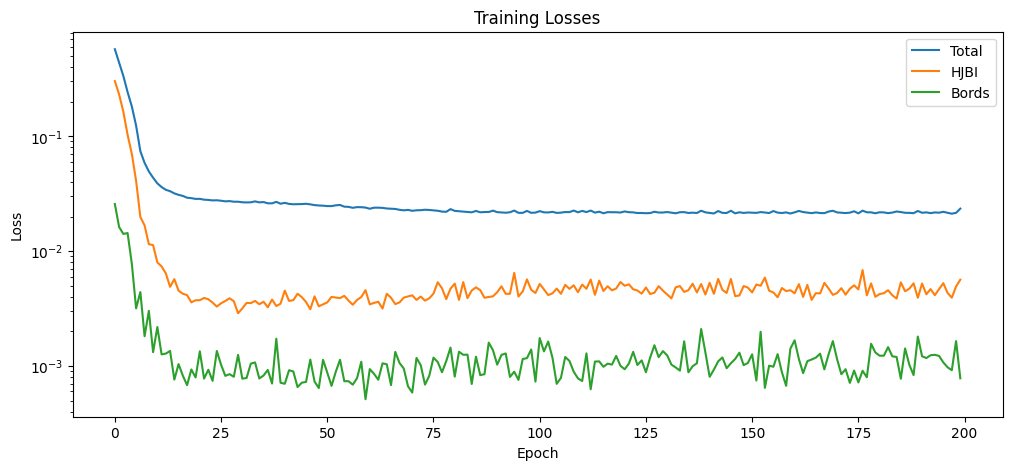

In [55]:
plt.figure(figsize=(12,5))

# Training
plt.plot(df_PI1["Loss Total"], label="Total")
plt.plot(df_PI1["Loss HJBI"], label="HJBI")
plt.plot(df_PI1["Loss Bords"], label="Bords")
plt.title("Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

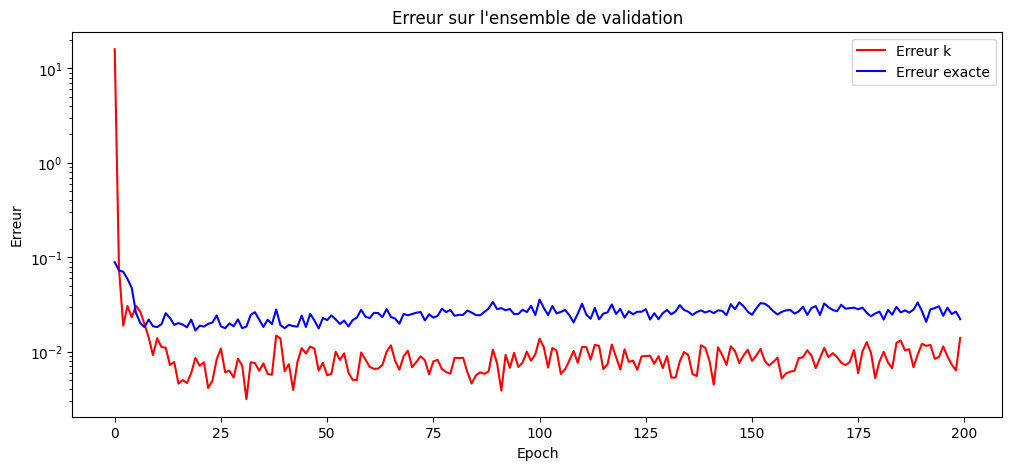

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(df_PI1["Erreur"], color='red', label='Erreur k')
plt.plot(df_PI1["Erreur exacte"], color='blue', label='Erreur exacte')
plt.title("Erreur sur l'ensemble de validation")
plt.xlabel("Epoch")
plt.ylabel("Erreur")
plt.yscale("log")
plt.legend()
plt.show()

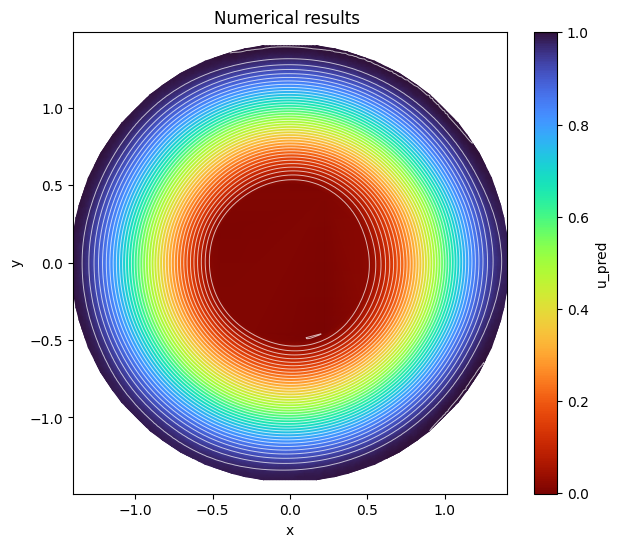

In [57]:
with torch.no_grad():
    u_pred = net(X_val).cpu().numpy()

x = X_val[:,0].cpu().numpy()
y = X_val[:,1].cpu().numpy()
u = u_pred.flatten()

plt.figure(figsize=(7,6))

# heatmap
heat = plt.tripcolor(x, y, u, shading="gouraud", cmap="turbo_r")

# lignes de niveau
plt.tricontour(x, y, u,levels=40,colors="white",linewidths=0.7,alpha=0.7)

# jauge de couleur associée à la heatmap
plt.colorbar(heat, label="u_pred")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerical results ")

plt.axis("equal")

plt.show()

#### Cas avec f=1

In [58]:
# Parameters
from pprint import pprint

print("Paramètres : \n")
params['f']=1
pprint(params)
print(f'Nombre de points au bord : {N_b}')
print(f'Nombre de points intérieurs : {N_F}')
print(f'Nombre de points de validation : {N_val}')

Paramètres : 

{'R': np.float64(1.4142135623730951),
 'a': 0.2,
 'f': 1,
 'kappa': 0.1,
 'r': 0.5,
 'sigma_x': 0.5,
 'sigma_y': 0.2,
 'v_s': 0.5}
Nombre de points au bord : 1000
Nombre de points intérieurs : 10000
Nombre de points de validation : 200


In [59]:
# INIT
net = fnn.NeuralNet().to(device)


# INITIALISATION
with torch.no_grad():
    u_k = net(X_val).detach().clone()
u_old = torch.zeros_like(u_k)

start = time.time()


# BOUCLE PRINCIPALE 
df = []
for k in range(1, kmax + 1):
    print(f"Iteration {k}\n=================================")

    # Reset optimizer à chaque itération k (important)
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    eta_k = 2 ** (-k)

    # norme précédente
    diff_prev = torch.norm(u_k - u_old).item()
    threshold = eta_k * min(diff_prev, eta_0)

    # BOUCLE SGD
    it = 0
    while True:

        perm = torch.randperm(N_F, device=device)

        for i in range(0, N_F, batch_size):
            idx = perm[i:i+batch_size]
            X_batch = X_F[idx].clone().detach().requires_grad_(True)

            hjbi_loss = fnn.pde_residual_loss(net, X_batch, params)
            bord_loss_r = fnn.boundary_l2_loss(net, X_b_r, g_bord_r, params['r'])
            bord_loss_R = fnn.boundary_l2_loss(net, X_b_R, g_bord_R, params['R'])
            h32_r = fnn.boundary_h32(net, theta1, theta2, params['r'])
            h32_R = fnn.boundary_h32(net, theta1, theta2, params['R'])

            loss = hjbi_loss + \
                   (bord_loss_r + 0.1 * h32_r) + \
                   (bord_loss_R + 0.1 * h32_R)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()

        # EVALUATION GLOBALE
        Jk_full, hjbi_full, loss_br, loss_bR = fnn.full_loss(net, X_val, params,X_b_r,X_b_R,g_bord_r,g_bord_R,theta1,theta2)
        Jk = Jk_full.item()

        # condition d'arrêt interne
        it += 1
        if (Jk < threshold) or (it < max_iter_):
            break

    # UPDATE u_k
    u_old = u_k.clone()
    with torch.no_grad():
        u_k = net(X_val).detach().clone()

    # ERREURS
    err = torch.norm(u_k - u_old) / (torch.norm(u_old) + 1e-12)

    elapsed = time.time() - start
    print(f"Temps écoulé : {elapsed:.2f} s\n-----------------------------------")

    df.append({
    "Loss Total": Jk,
    "Loss HJBI": hjbi_full.item(),
    "Loss Bords": (loss_br.item() + loss_bR.item()),
    "Erreur": err.item(),
    "Temps": elapsed
    })

    print(f"Loss Total : {Jk:.3e} | HBJI : {hjbi_full:.3e} | Loss bords : {loss_br + loss_bR:.3e} \n"
          f"Erreur :{err:.3e}\n")


    # STOP GLOBAL
    # if err <= tol:
    #     print("Convergence atteinte.")
    #     break

df_PI2 = pd.DataFrame(df)

Iteration 1
Temps écoulé : 1.76 s
-----------------------------------
Loss Total : 2.873e+00 | HBJI : 1.367e+00 | Loss bords : 1.249e+00 
Erreur :1.381e+01

Iteration 2
Temps écoulé : 3.63 s
-----------------------------------
Loss Total : 2.557e+00 | HBJI : 1.313e+00 | Loss bords : 1.045e+00 
Erreur :1.097e-01

Iteration 3
Temps écoulé : 5.51 s
-----------------------------------
Loss Total : 2.374e+00 | HBJI : 1.273e+00 | Loss bords : 9.061e-01 
Erreur :1.071e-01

Iteration 4
Temps écoulé : 7.60 s
-----------------------------------
Loss Total : 2.169e+00 | HBJI : 1.042e+00 | Loss bords : 8.680e-01 
Erreur :7.712e-02

Iteration 5
Temps écoulé : 9.53 s
-----------------------------------
Loss Total : 2.020e+00 | HBJI : 8.789e-01 | Loss bords : 8.116e-01 
Erreur :9.291e-02

Iteration 6
Temps écoulé : 11.38 s
-----------------------------------
Loss Total : 1.882e+00 | HBJI : 8.953e-01 | Loss bords : 5.946e-01 
Erreur :7.933e-02

Iteration 7
Temps écoulé : 13.21 s
----------------------

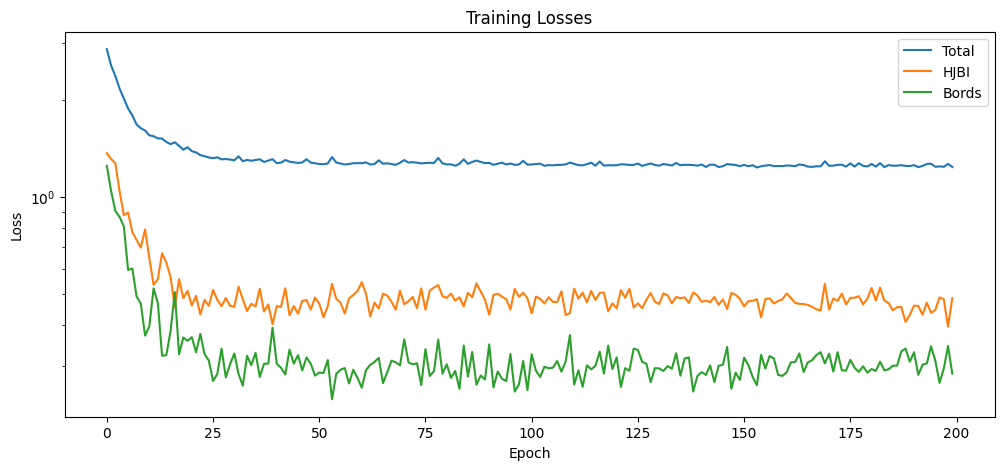

In [60]:
plt.figure(figsize=(12,5))

# Training
plt.plot(df_PI2["Loss Total"], label="Total")
plt.plot(df_PI2["Loss HJBI"], label="HJBI")
plt.plot(df_PI2["Loss Bords"], label="Bords")
plt.title("Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

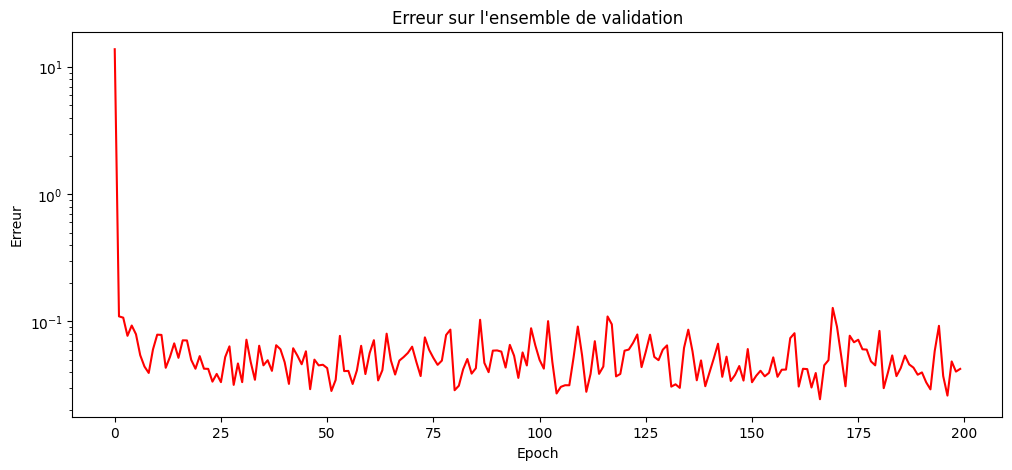

In [61]:
plt.figure(figsize=(12, 5))
plt.plot(df_PI2["Erreur"], color='red')
plt.title("Erreur sur l'ensemble de validation")
plt.xlabel("Epoch")
plt.ylabel("Erreur")
plt.yscale("log")
plt.show()

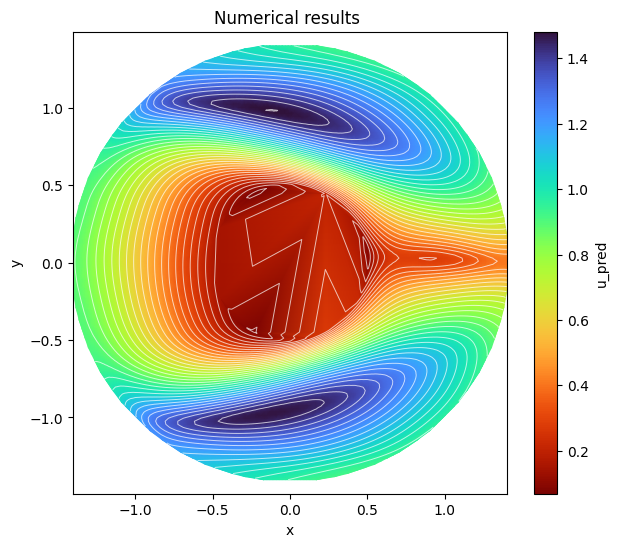

In [62]:
with torch.no_grad():
    u_pred = net(X_val).cpu().numpy()

x = X_val[:,0].cpu().numpy()
y = X_val[:,1].cpu().numpy()
u = u_pred.flatten()

plt.figure(figsize=(7,6))

# heatmap
heat = plt.tripcolor(x, y, u, shading="gouraud", cmap="turbo_r")

# lignes de niveau
plt.tricontour(x, y, u,levels=40,colors="white",linewidths=0.7,alpha=0.7)

# jauge de couleur associée à la heatmap
plt.colorbar(heat, label="u_pred")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerical results ")

plt.axis("equal")

plt.show()

# Comparison

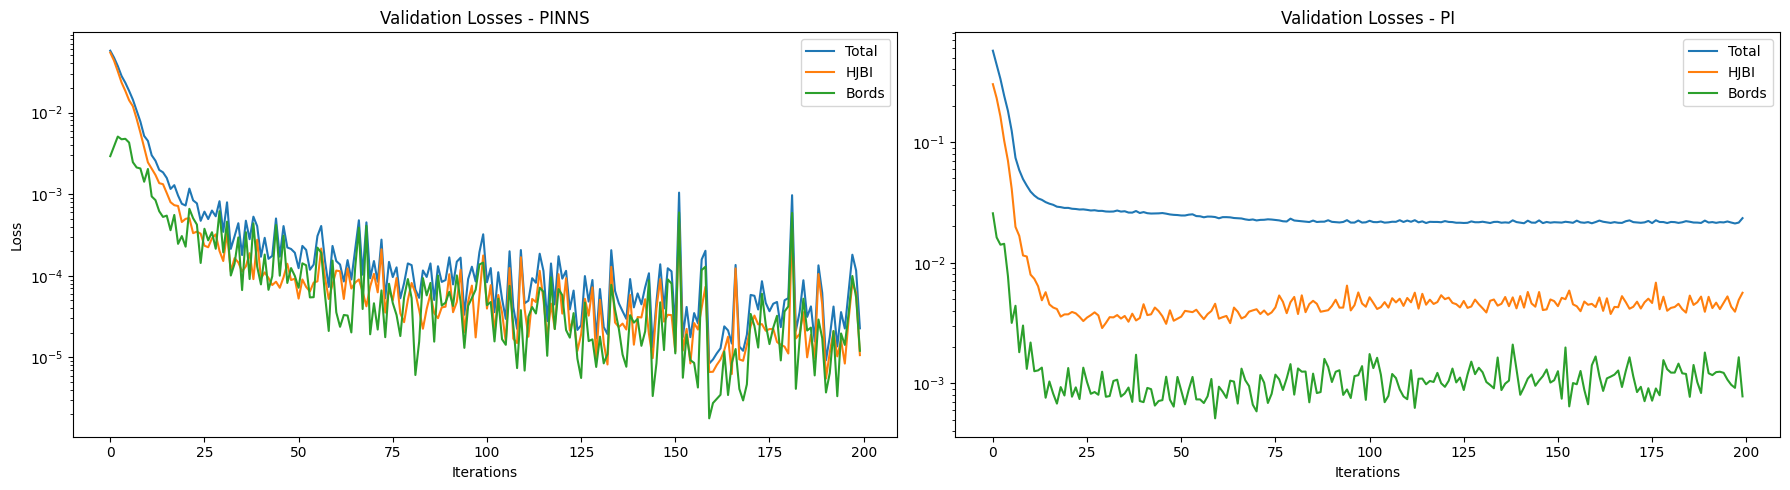

In [63]:
fig, ax = plt.subplots(1,2, figsize=(18,5))

# Training
ax[0].plot(df_pinns_1["Validation Loss Total"], label="Total")
ax[0].plot(df_pinns_1["Validation Loss HJBI"], label="HJBI")
ax[0].plot(df_pinns_1["Validation Loss Bords"], label="Bords")
ax[0].set_title("Validation Losses - PINNS")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("Loss")
ax[0].set_yscale("log")
ax[0].legend()

# Validation
ax[1].plot(df_PI1["Loss Total"], label="Total")
ax[1].plot(df_PI1["Loss HJBI"], label="HJBI")
ax[1].plot(df_PI1["Loss Bords"], label="Bords")
ax[1].set_title("Validation Losses - PI")
ax[1].set_xlabel("Iterations")
ax[1].set_yscale("log")
ax[1].legend()

plt.tight_layout()
plt.show()